In [2]:
import sys
sys.path.append(r'C:\Users\sadiq\Desktop\U_Vienna\codes\icm-zebrafish')
sys.path.append(r'C:/Users/sadiq/Desktop/U_Vienna/codes/icm-zebrafish/Mathilde/new_data_09112022/220119_F2_run11')
%matplotlib inline
import numpy as np
from new_utils import *
from d_CSL import *
import pickle
import matplotlib.pyplot as plt
from scipy.signal import resample
from mpl_toolkits.mplot3d import axes3d
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.animation as animation

In [3]:
%reload_ext autoreload
%autoreload 2
from d_CSL import *

In [3]:
traces = np.load('220119_F2_F2_run11_cells_fluorescence_signals.npy')
tail_angle= np.load('220119_F2_F2_run11_tail_angle.npy')
registration = np.load('220119_F2_F2_run11_registered_cells_pos.npy')
all_positions = np.load('220119_F2_F2_run11_cells_positions.npy')
emitter_idx = np.load('220119_F2_F2_run11_emitter_cells.npy')
reciever_idx = np.load('220119_F2_F2_run11_receiver_cells.npy')
mean_background = np.load('220119_F2_F2_run11_mean_background.npy')
bad_frames = [13,87,88,975,1253,1555,1556,1700,1701,1761,2268,3003]

In [26]:
def rotate(angle):
    ax.view_init(azim=angle)

In [5]:
print(traces.shape)
print(len(emitter_idx))
print(emitter_idx)
print(len(reciever_idx))
print(reciever_idx)
ER_idx = np.r_[emitter_idx,reciever_idx]
print(ER_idx)

(1010, 3613)
31
[ 54  55  61 130 133 142 154 193 194 195 275 276 280 290 294 298 453 471
 501 619 622 642 644 693 699 700 704 721 968 984 999]
69
[  4  12  14  30  34  36  70  73  77  96  97 102 103 217 227 228 235 245
 246 251 257 310 317 337 348 352 365 388 405 411 416 427 432 433 435 472
 473 478 498 521 540 541 542 570 571 575 580 617 620 647 651 665 675 717
 755 764 770 796 798 801 807 810 823 824 828 829 881 886 928]
[ 54  55  61 130 133 142 154 193 194 195 275 276 280 290 294 298 453 471
 501 619 622 642 644 693 699 700 704 721 968 984 999   4  12  14  30  34
  36  70  73  77  96  97 102 103 217 227 228 235 245 246 251 257 310 317
 337 348 352 365 388 405 411 416 427 432 433 435 472 473 478 498 521 540
 541 542 570 571 575 580 617 620 647 651 665 675 717 755 764 770 796 798
 801 807 810 823 824 828 829 881 886 928]


In [27]:
arr = list(ER_idx)

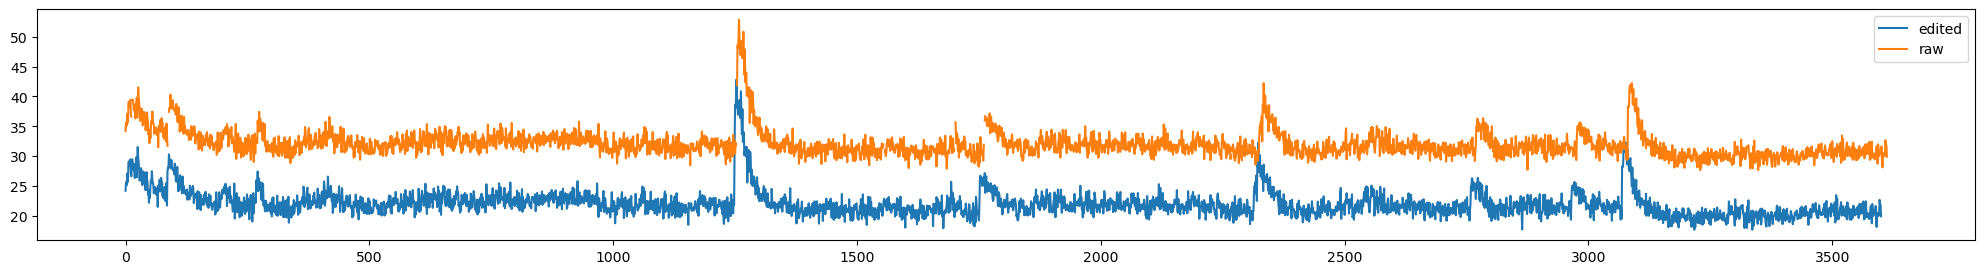

In [6]:
new_traces = replace_nan_(traces,bad_frames,delete_frames=True)
plt.figure(figsize=(25,3))
plt.plot(new_traces[1],label='edited')
plt.plot(traces[1]+10,label='raw')
plt.legend()
# plt.xlim([0,100])

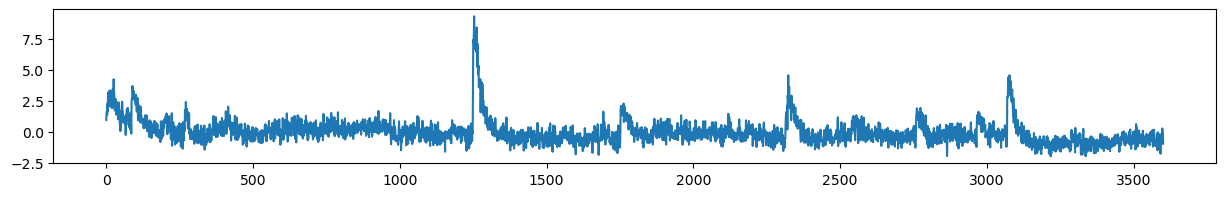

In [7]:
plt.figure(figsize=(15,2))
plt.plot((new_traces[1]-np.mean(new_traces[1]))/np.std(new_traces[1]))
np.save('trace',new_traces[1]/np.max(new_traces[1]))

In [8]:
len(emitter_idx)

31

In [9]:
X = new_traces[ER_idx]

In [10]:
X.shape

(100, 3601)

<IPython.core.display.Javascript object>


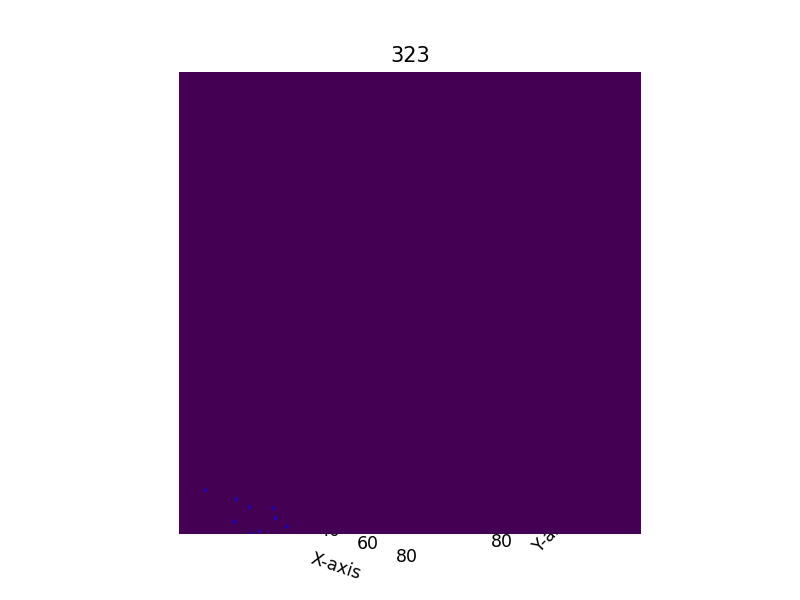

Text(0.5, 0, 'z-axis')

In [11]:
%matplotlib notebook
fig = plt.figure()
ax = fig.add_subplot(111,projection="3d")
ax.scatter(all_positions[:,0],all_positions[:,1],all_positions[:,2],color='blue',s=10,marker='.')
ax.scatter(all_positions[emitter_idx,0],all_positions[emitter_idx,1],all_positions[emitter_idx,2],color='red',s=30,marker='o')
ax.scatter(all_positions[reciever_idx,0],all_positions[reciever_idx,1],all_positions[reciever_idx,2],color='green',s=30,marker='o')
ax.grid(False)
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('z-axis')

## Analysis

In [12]:
alpha,beta,n_neur = 0.01,0.001,X.shape[0]

#### GC adaptation

In [13]:
%%time
infs = []
for n in list(range(1,5)):
    print(f'n_pasts = {n}')
    corr,pVal_corr,inv_corr,pVal_inv_corr = analysis_GC(X,1000,n)
    infs.append(proceed_GC_new(corr,pVal_corr,inv_corr,pVal_inv_corr,alpha,beta,n))

n_pasts = 1
n_pasts = 2
n_pasts = 3
n_pasts = 4
CPU times: total: 2d 13h 6min 21s
Wall time: 1d 9h 57min 57s


<IPython.core.display.Javascript object>


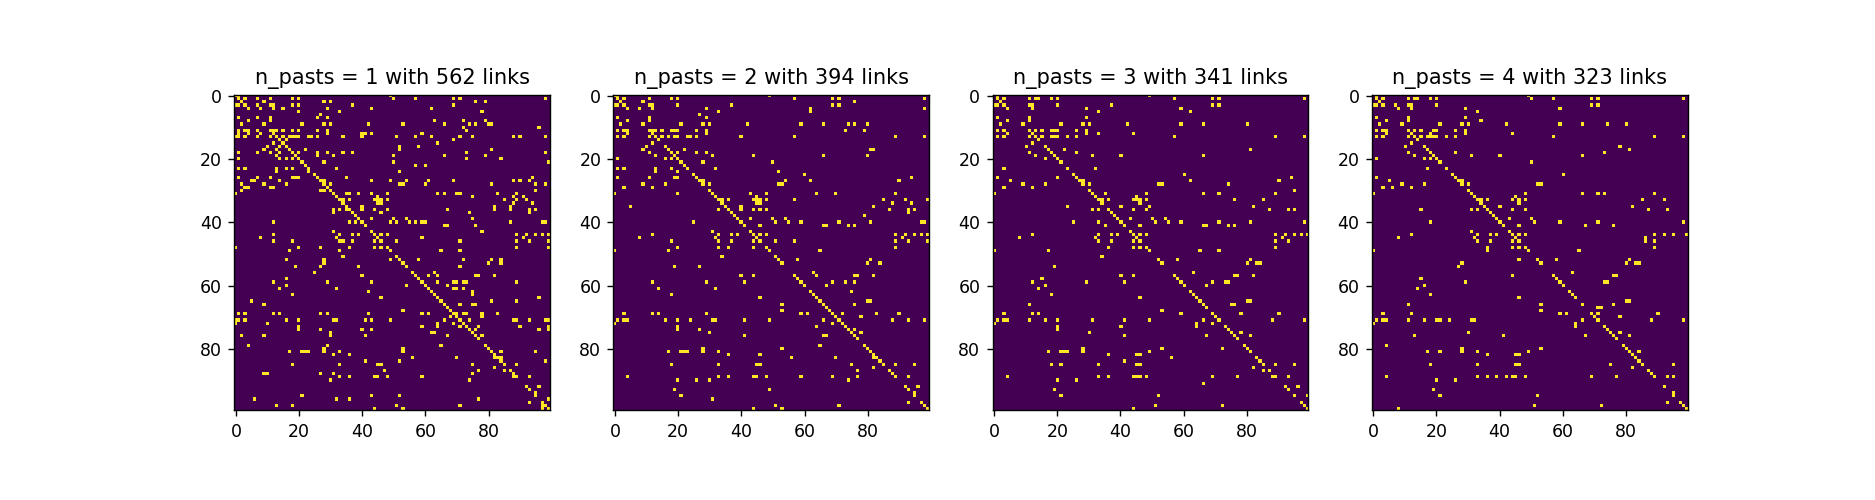

In [14]:
fig,ax= plt.subplots(1,len(infs),figsize=(15,4))
for i, el in enumerate(infs):
    ax[i].imshow(el)
    ax[i].set_title(f'n_pasts = {i+1} with {np.sum(el)} links')

In [15]:
%store -r a b c

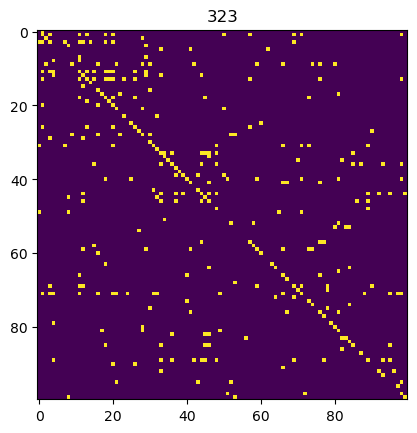

In [19]:
plt.imshow(a)
plt.title(np.sum(a))
plt.show()

Text(0.5, 1.0, '215')

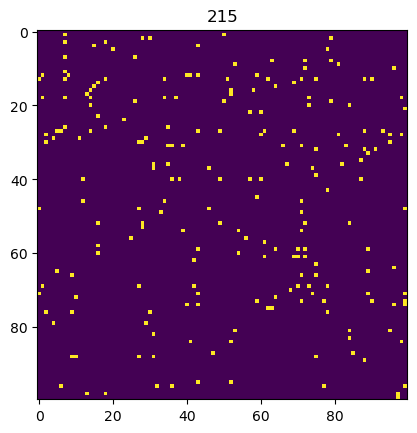

In [20]:
k = diff_(infs[0],infs[1])
plt.imshow(k)
plt.title(np.sum(k))

In [21]:
infs_ = infs + [a,b,c]
infs_[3]


array([[False,  True, False, ..., False, False, False],
       [False,  True, False, ..., False,  True, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False, False,  True]])

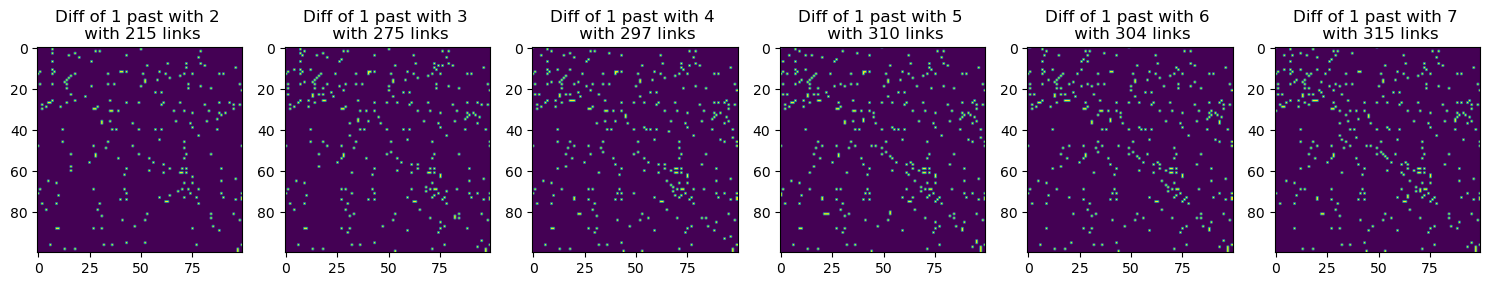

In [22]:
fig,ax= plt.subplots(1,len(infs_)-1,figsize=(15,4))
for i in range(1,len(infs_)):
    ax[i-1].imshow(diff_(infs_[0],infs_[i]))
    ax[i-1].set_title(f'Diff of 1 past with {i+1} \n with {np.sum(diff_(infs_[0],infs_[i]))} links')
plt.tight_layout()

Checking the difference in the inferred matrices across number of pasts considered  

Number of links NOT inferred with 1 past that are inferred by others $n_{pasts}$ considered

<IPython.core.display.Javascript object>


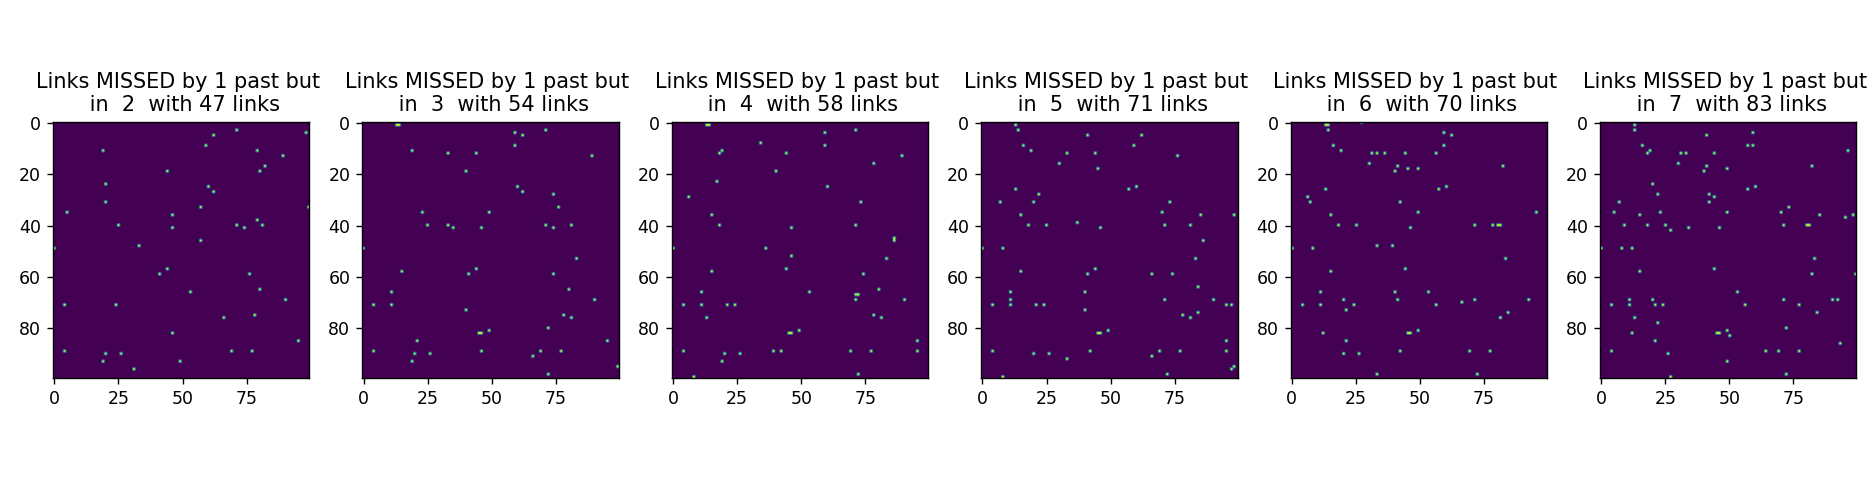

In [51]:
fig,ax= plt.subplots(1,len(infs_)-1,figsize=(15,4))
for i in range(1,len(infs_)):
    ax[i-1].imshow(diff_(infs_[i],infs_[0]))
    ax[i-1].set_title(f'Links MISSED by 1 past but \n in  {i+1}  with {np.sum(diff_(infs_[i], infs_[0]))} links')
plt.tight_layout()

In [ ]:
# continue for other things

In [23]:
results = {}
for i in range(1,len(infs_)+1):
    results[i] = infs_[i-1] 

In [24]:
import pickle 

with open('results.pkl', 'wb') as f:
    pickle.dump(results, f)

Text(0.5, 1.0, '562')

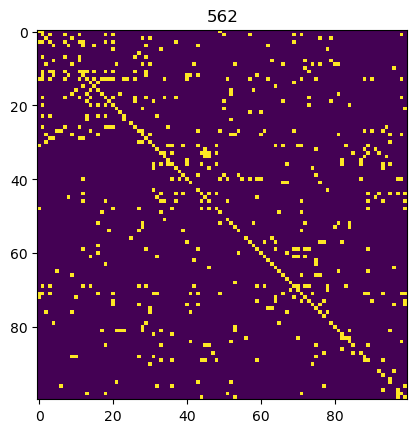

In [25]:
plt.imshow(results[1])
plt.title(np.sum(results[1]))

<IPython.core.display.Javascript object>


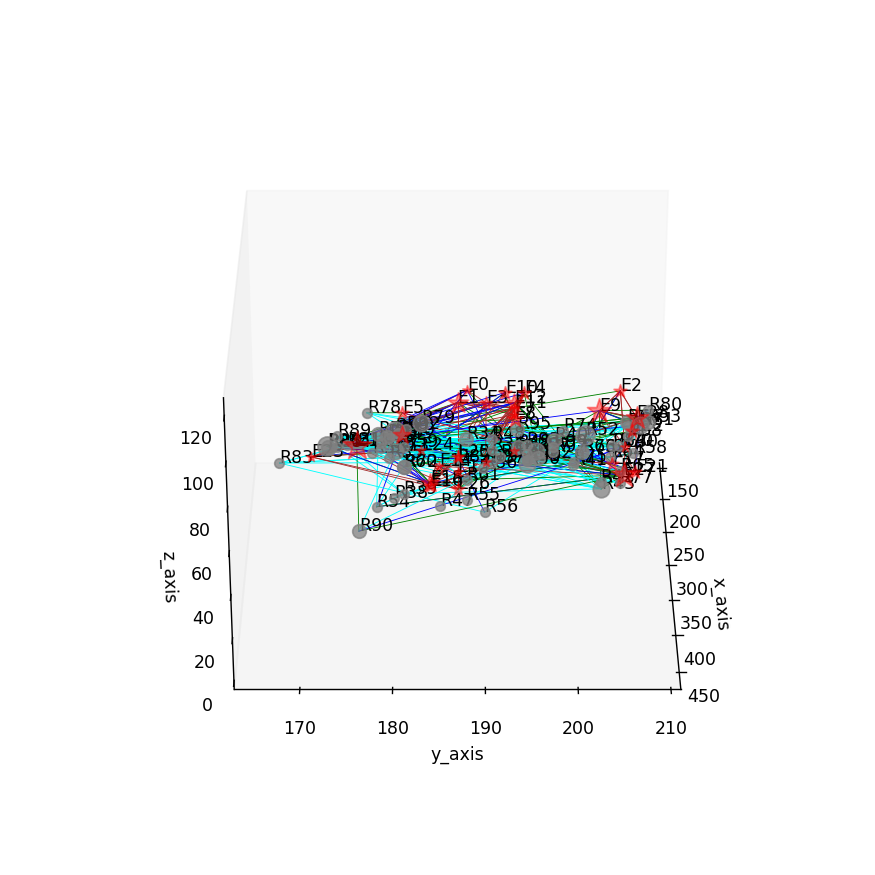

MovieWriter imagemagick unavailable; using Pillow instead.


<IPython.core.display.Javascript object>


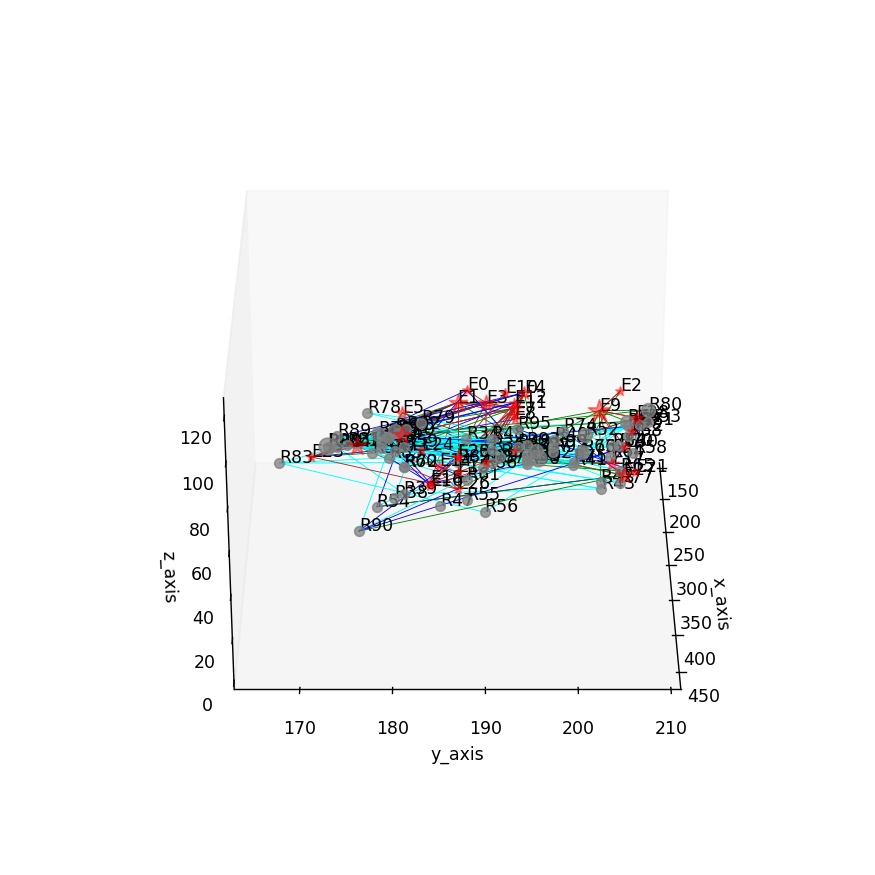

MovieWriter imagemagick unavailable; using Pillow instead.


<IPython.core.display.Javascript object>


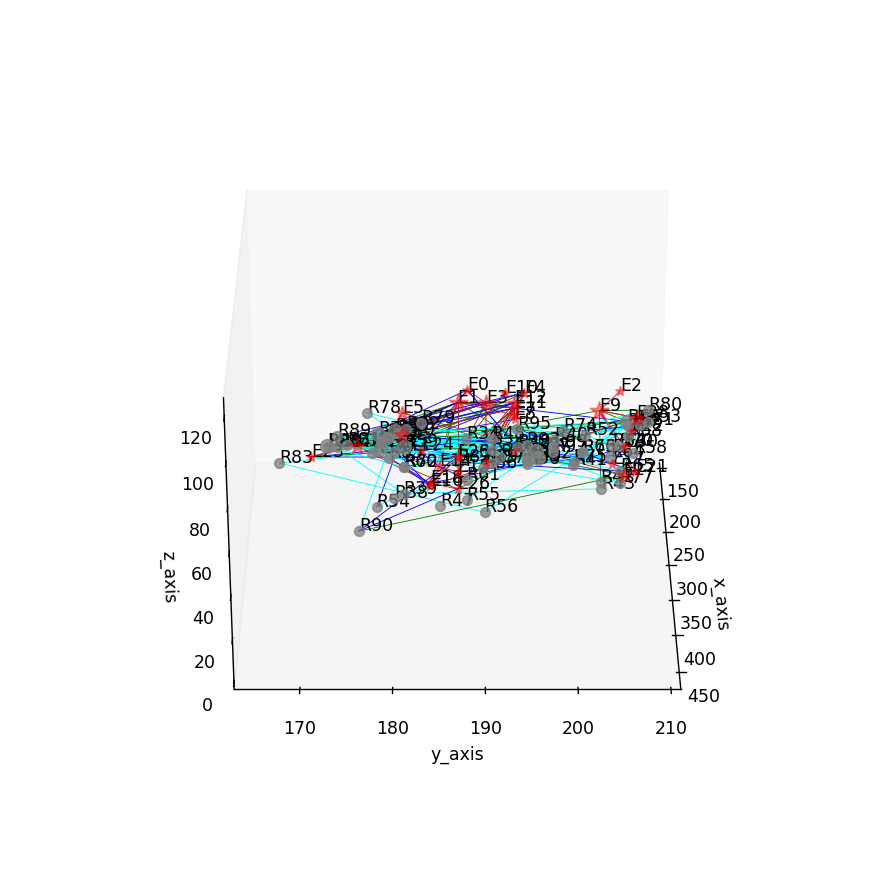

MovieWriter imagemagick unavailable; using Pillow instead.


<IPython.core.display.Javascript object>


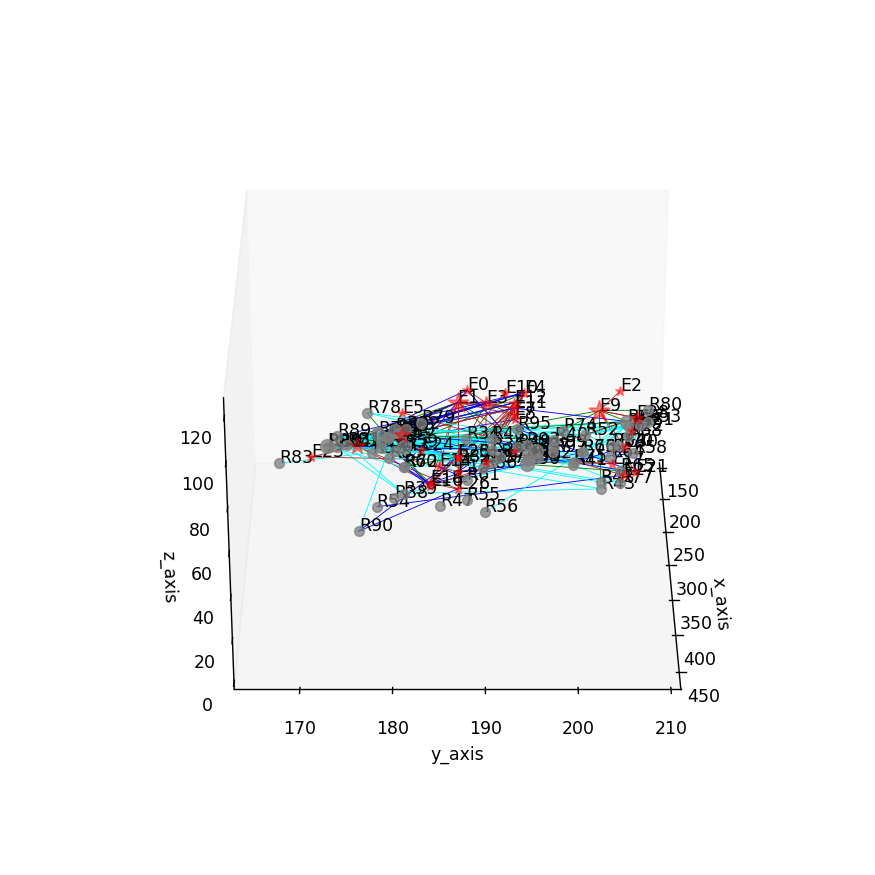

MovieWriter imagemagick unavailable; using Pillow instead.


<IPython.core.display.Javascript object>


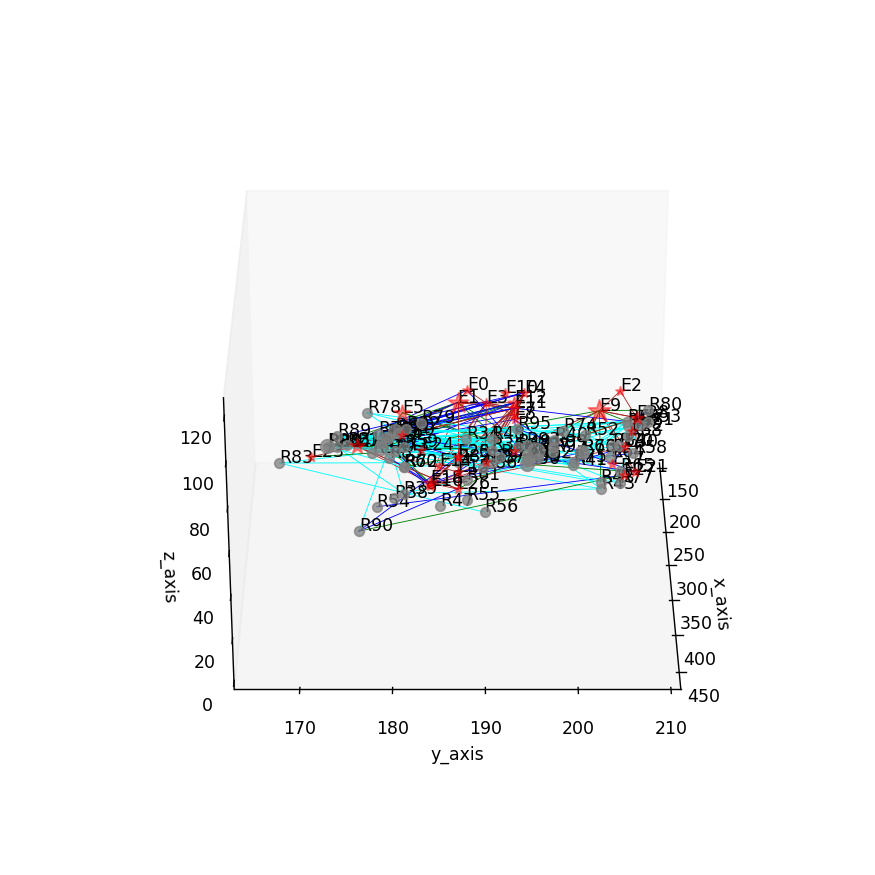

MovieWriter imagemagick unavailable; using Pillow instead.


<IPython.core.display.Javascript object>


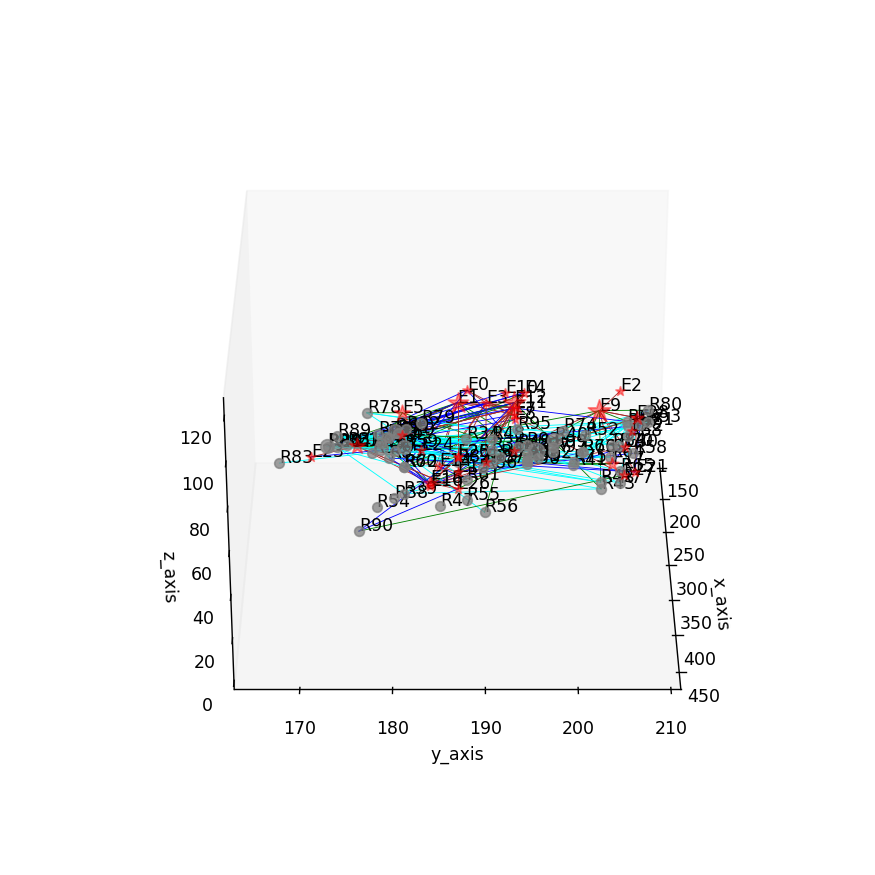

MovieWriter imagemagick unavailable; using Pillow instead.


<IPython.core.display.Javascript object>


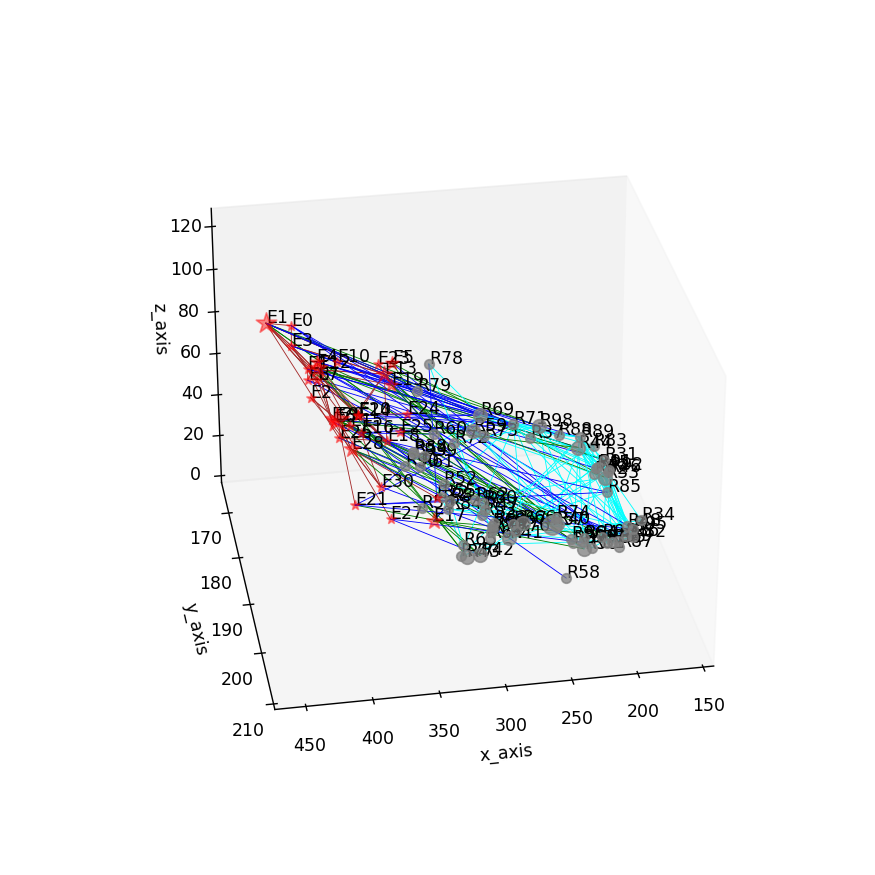

MovieWriter imagemagick unavailable; using Pillow instead.


In [28]:
%matplotlib notebook
for z, el in enumerate(infs_):
    el_ = repopulate(el,new_traces,arr)
    edges_out,edges_in = vertixDegree(el_)
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111,projection="3d")
    for j, i in enumerate(arr):
        if i in emitter_idx:
            out_, _ = counter_(edges_out[i],edges_in[i],emitter_idx,reciever_idx)
            if out_>0: 
                ax.scatter(all_positions[i,0],all_positions[i,1],all_positions[i,2],color='red',s=30*out_+1,alpha=.45,marker='*')
                ax.text(all_positions[i,0],all_positions[i,1],all_positions[i,2], s=f'E{j}')
            else:
                ax.scatter(all_positions[i,0],all_positions[i,1],all_positions[i,2],color='red',s=30,alpha=.45,marker='*')
                ax.text(all_positions[i,0],all_positions[i,1],all_positions[i,2], s=f'E{j}')
        else:
            _, in_ = counter_(edges_out[i],edges_in[i],emitter_idx,reciever_idx)
            if in_>0:
                ax.scatter(all_positions[i,0],all_positions[i,1],all_positions[i,2],color='gray',s=30*in_+1,alpha=.75,marker='o')
                ax.text(all_positions[i,0],all_positions[i,1],all_positions[i,2], s=f'R{j}')
            else:
                ax.scatter(all_positions[i,0],all_positions[i,1],all_positions[i,2],color='gray',s=30,alpha=.75,marker='o')
                ax.text(all_positions[i,0],all_positions[i,1],all_positions[i,2], s=f'R{j}')

    x_val,y_val,z_val,prec = xyz_maker(el_,all_positions)

    inf = el.flatten()[np.where(el.flatten()!=0)[0]]
    for a in range(len(x_val)):
        if prec[a][0] in emitter_idx and prec[a][1] in emitter_idx: 
            ax.plot(x_val[a],y_val[a],z_val[a],lw=0.5,c='brown')
        elif prec[a][0] in emitter_idx and prec[a][1] in reciever_idx:
            ax.plot(x_val[a],y_val[a],z_val[a],lw=0.5,c='green')  
        elif prec[a][0] in reciever_idx and prec[a][1] in reciever_idx:
            ax.plot(x_val[a],y_val[a],z_val[a],lw=0.5,c='cyan')
        elif prec[a][0] in reciever_idx and prec[a][1] in emitter_idx:
            ax.plot(x_val[a],y_val[a],z_val[a],lw=0.5,c='blue')
    ax.grid(False)
    ax.set_xlabel('x_axis')
    ax.set_ylabel('y_axis')
    ax.set_zlabel('z_axis')
    rot_animation = animation.FuncAnimation(fig, rotate, frames=np.arange(0, 362, 2), interval=50)
    rot_animation.save('./markovianity/{}_pasts.gif'.format(z+1),dpi=80, writer='imagemagick')

In [33]:
def compare_(inf,em,rec):
    """
    inf_a is matrix of 1 past
    inf_b can be any other number of pasts
    em is emitter_idx
    rec is receiver_idx
    """
    diffs = {'em2rec':[],
             'rec2em':[],
             'em2em':[],
             'rec2rec':[]}
    em2rec,rec2em = inf[0][:len(em),len(em):],inf[0][len(em):,:len(em)]
    em2em,rec2rec = inf[0][:len(em),:len(em)],inf[0][len(em):,len(em):]
    for i in range(1,len(infs_)):
        em2rec_b,rec2em_b = inf[i][:len(em),len(em):],inf[i][len(em):,:len(em)]
        em2em_b,rec2rec_b = inf[i][:len(em),:len(em)],inf[i][len(em):,len(em):]

        diffs['em2rec'].append(np.sum(diff_(em2rec,em2rec_b)))
        diffs['rec2em'].append(np.sum(diff_(rec2em,rec2em_b)))
        diffs['em2em'].append(np.sum(diff_(em2em,em2em_b)))
        diffs['rec2rec'].append(np.sum(diff_(rec2rec,rec2rec_b)))
    
    return diffs

def compare_2(inf,em,rec):
    """
    inf_a is matrix of 1 past
    inf_b can be any other number of pasts
    em is emitter_idx
    rec is receiver_idx
    """
    diffs_2 = {'em2rec':[],
             'rec2em':[],
             'em2em':[],
             'rec2rec':[]}
    em2rec,rec2em = inf[0][:len(em),len(em):],inf[0][len(em):,:len(em)]
    em2em,rec2rec = inf[0][:len(em),:len(em)],inf[0][len(em):,len(em):]
    for i in range(1,len(infs_)):
        em2rec_b,rec2em_b = inf[i][:len(em),len(em):],inf[i][len(em):,:len(em)]
        em2em_b,rec2rec_b = inf[i][:len(em),:len(em)],inf[i][len(em):,len(em):]

        diffs_2['em2rec'].append(np.sum(diff_(em2rec_b, em2rec)))
        diffs_2['rec2em'].append(np.sum(diff_(rec2em_b, rec2em)))
        diffs_2['em2em'].append(np.sum(diff_(em2em_b, em2em)))
        diffs_2['rec2rec'].append(np.sum(diff_(rec2rec_b, rec2rec)))
    
    return diffs_2

In [30]:
diffs = compare_(infs_,emitter_idx,reciever_idx) 

In [1]:
diffs = {'em2rec': [50, 58, 59, 59, 59, 58],
         'rec2em': [27, 32, 37, 39, 34, 35],
         'em2em': [38, 57, 56, 57, 60, 66],
         'rec2rec': [100, 128, 145, 155, 151, 156]}



Text(0.5, 1.0, 'Links weeded out in 1 past with increasing number of pasts')

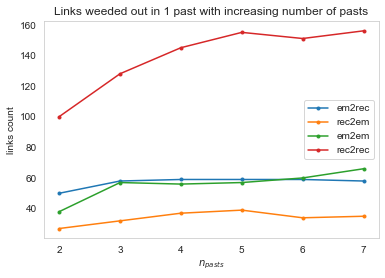

In [4]:
plt.plot(np.arange(2,8),diffs['em2rec'],marker='.',label='em2rec')
plt.plot(np.arange(2,8),diffs['rec2em'],marker='.',label='rec2em')
plt.plot(np.arange(2,8),diffs['em2em'],marker='.',label='em2em')
plt.plot(np.arange(2,8),diffs['rec2rec'],marker='.',label='rec2rec')
plt.grid()
plt.legend()
plt.xlabel('$n_{pasts}$')
plt.ylabel('links count')
plt.title('Links weeded out in 1 past with increasing number of pasts')

<IPython.core.display.Javascript object>


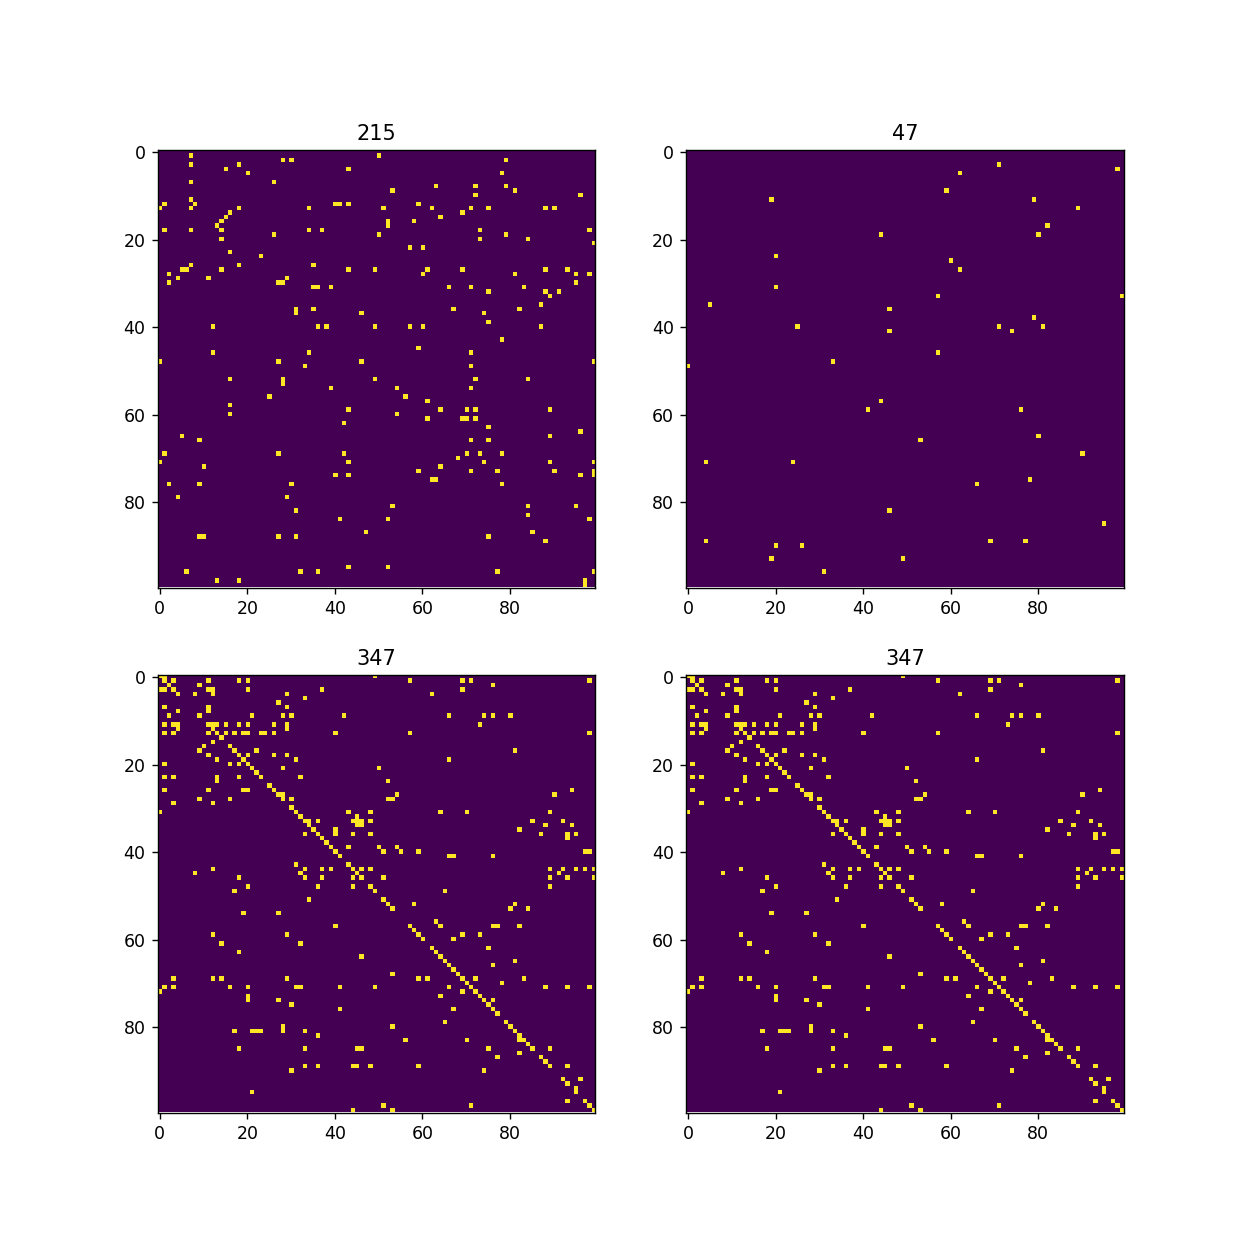

Text(0.5, 1.0, '347')

In [45]:
fig,ax = plt.subplots(2,2,figsize=(10,10))

ax[0,0].imshow(diff_(infs_[0],infs_[1]))
ax[0,0].set_title(f'{np.sum(diff_(infs_[0],infs_[1]))}')
ax[0,1].imshow(diff_(infs_[1],infs_[0]))
ax[0,1].set_title(f'{np.sum(diff_(infs_[1],infs_[0]))}')

ax[1,0].imshow(np.logical_and(infs_[0],infs_[1]))
ax[1,0].set_title(f'{np.sum(np.logical_and(infs_[0],infs_[1]))}')
ax[1,1].imshow(np.logical_and(infs_[1],infs_[0]))
ax[1,1].set_title(f'{np.sum(np.logical_and(infs_[1],infs_[0]))}')


In [35]:
diffs_2 = compare_2(infs_,emitter_idx,reciever_idx) 

In [5]:
diffs_2 = {'em2rec': [11, 11, 9, 9, 15, 16],
 'rec2em': [10, 12, 15, 18, 17, 25],
 'em2em': [2, 3, 6, 7, 9, 8],
 'rec2rec': [24, 28, 28, 37, 29, 34]}

Text(0.5, 1.0, 'Links excluded in 1 past but included in increasing $n\\_past$')

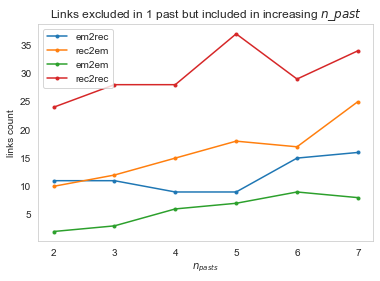

In [6]:
plt.plot(np.arange(2,8),diffs_2['em2rec'],marker='.',label='em2rec')
plt.plot(np.arange(2,8),diffs_2['rec2em'],marker='.',label='rec2em')
plt.plot(np.arange(2,8),diffs_2['em2em'],marker='.',label='em2em')
plt.plot(np.arange(2,8),diffs_2['rec2rec'],marker='.',label='rec2rec')
plt.grid()
plt.legend()
plt.xlabel('$n_{pasts}$')
plt.ylabel('links count')
plt.title('Links excluded in 1 past but included in increasing $n\_past$')

#### Connection in a given lag matrix that are not in matrix of $n_{past}$ = 1 

In [ ]:
# continue here

<IPython.core.display.Javascript object>


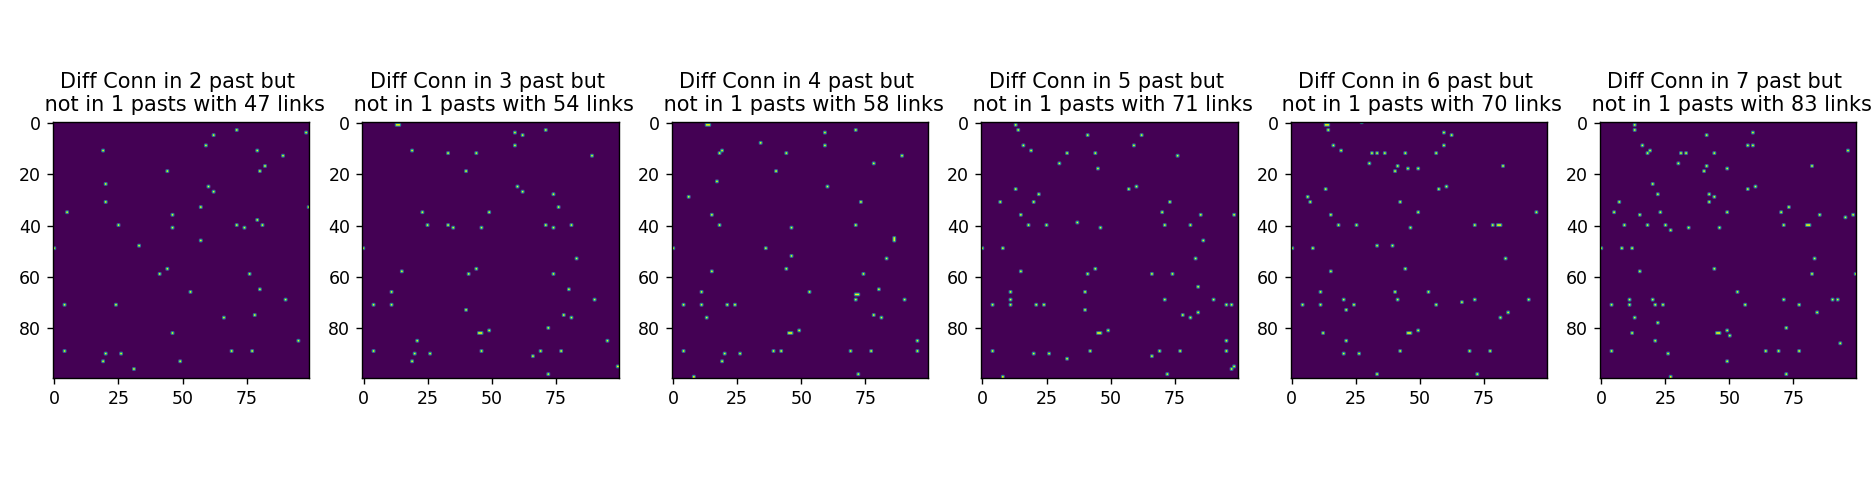

In [54]:
fig,ax= plt.subplots(1,len(infs_)-1,figsize=(15,4))
D = []
for i in range(1,len(infs_)):
    d_ = diff_(infs_[i],infs_[0])
    D.append(d_)
    ax[i-1].imshow(d_)
    ax[i-1].set_title(f'Diff Conn in {i+1} past but \n not in 1 pasts with {np.sum(diff_(infs_[i], infs_[0]))} links')
plt.tight_layout()

<IPython.core.display.Javascript object>


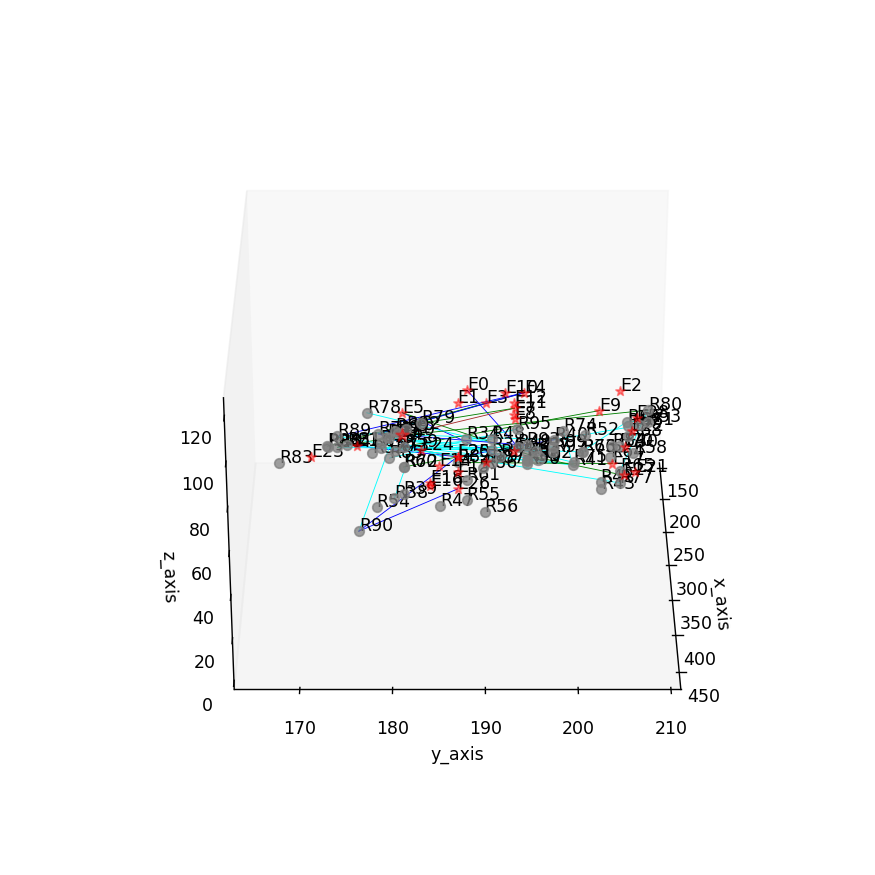

MovieWriter imagemagick unavailable; using Pillow instead.


<IPython.core.display.Javascript object>


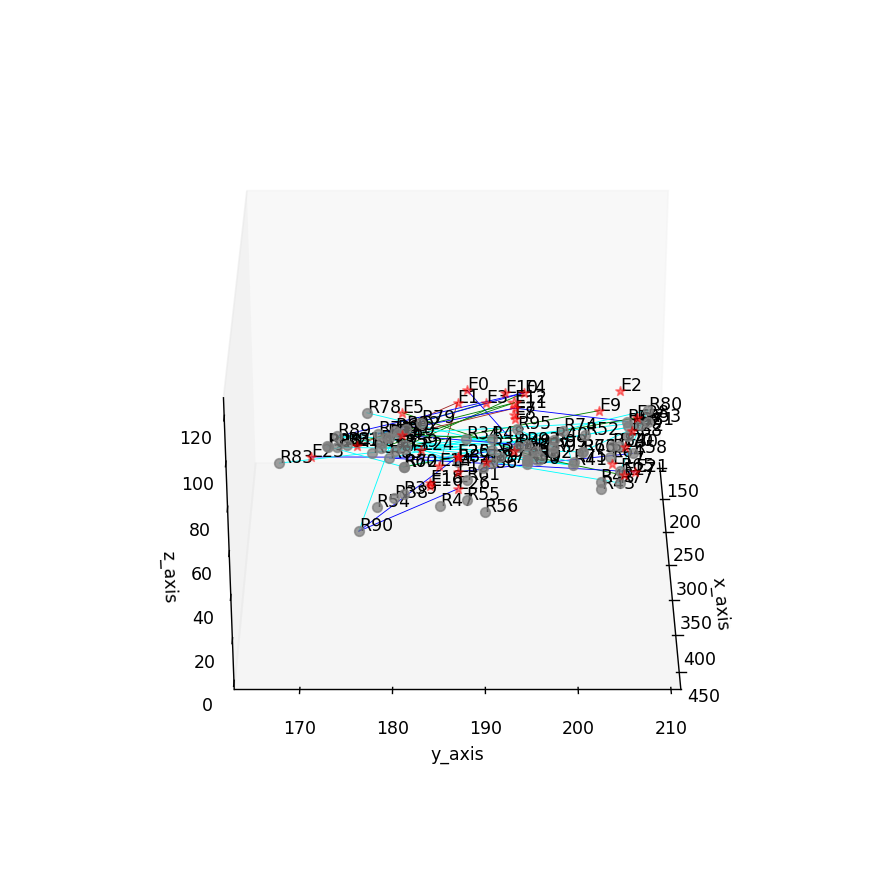

MovieWriter imagemagick unavailable; using Pillow instead.


<IPython.core.display.Javascript object>


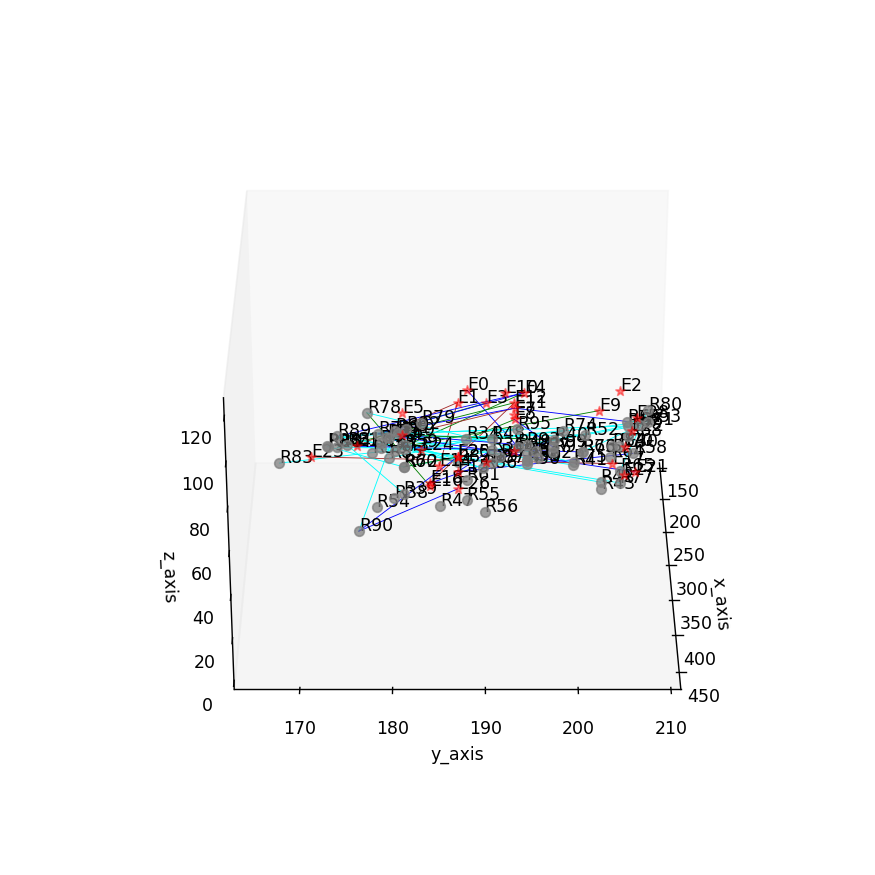

MovieWriter imagemagick unavailable; using Pillow instead.


<IPython.core.display.Javascript object>


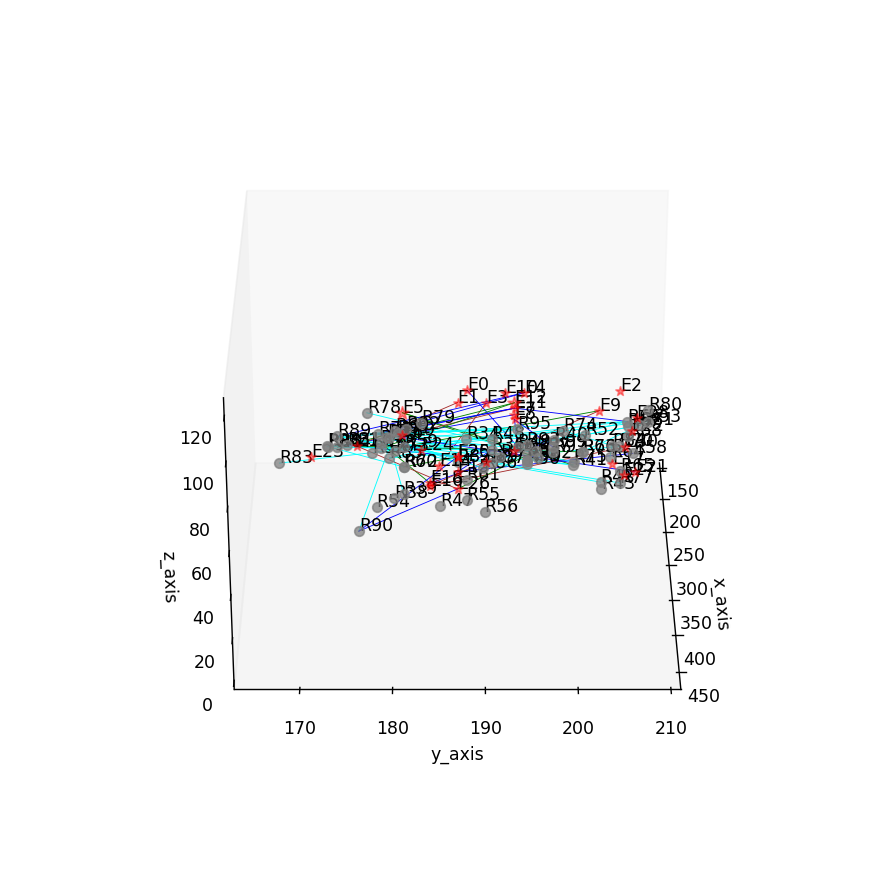

MovieWriter imagemagick unavailable; using Pillow instead.


<IPython.core.display.Javascript object>


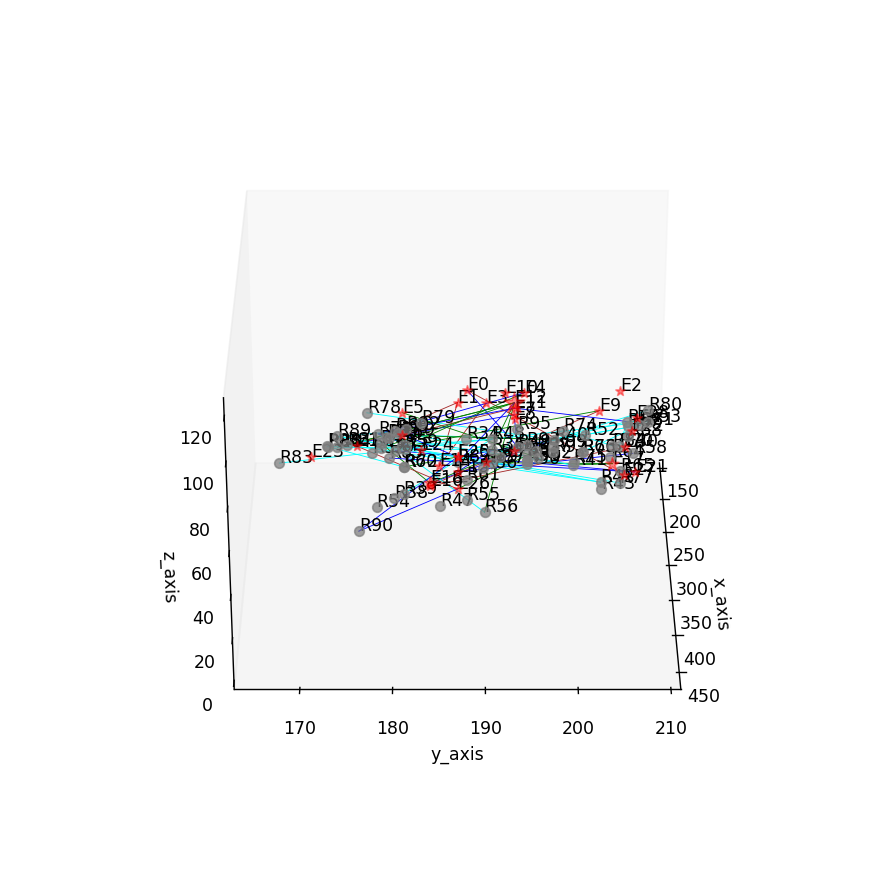

MovieWriter imagemagick unavailable; using Pillow instead.


<IPython.core.display.Javascript object>


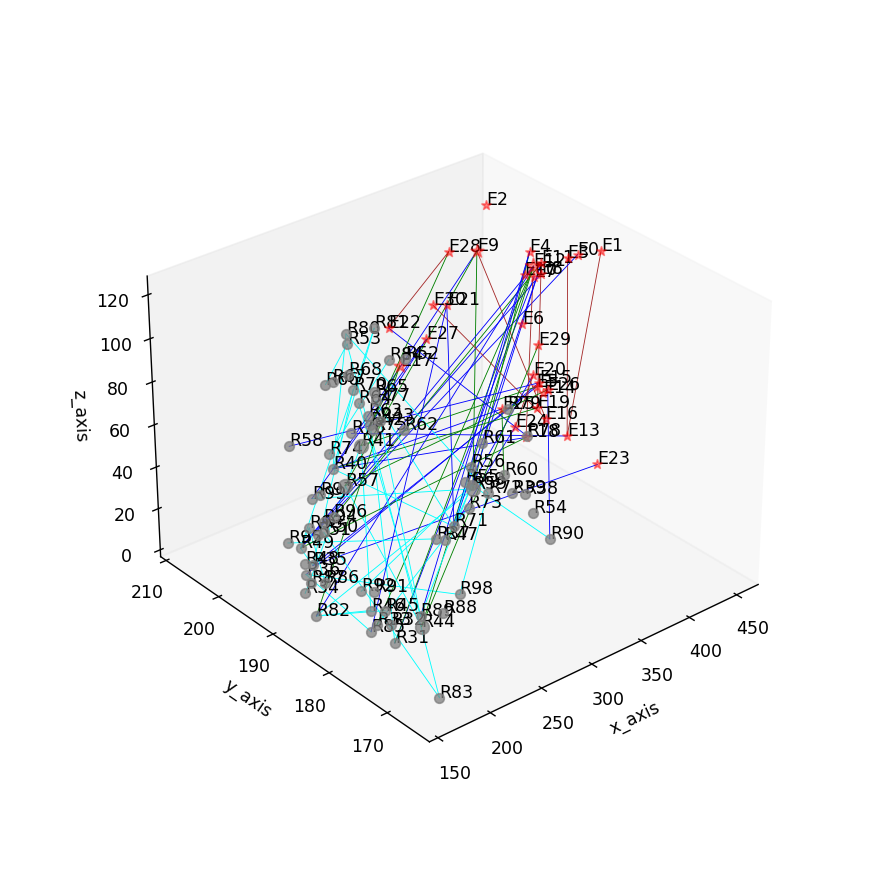

MovieWriter imagemagick unavailable; using Pillow instead.


In [55]:
%matplotlib notebook
for z, el in enumerate(D):
    el_ = repopulate(el,new_traces,arr)
    edges_out,edges_in = vertixDegree(el_)
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111,projection="3d")
    for j, i in enumerate(arr):
        if i in emitter_idx:
            out_, _ = counter_(edges_out[i],edges_in[i],emitter_idx,reciever_idx)
            if out_>0: 
                ax.scatter(all_positions[i,0],all_positions[i,1],all_positions[i,2],color='red',s=30*out_+1,alpha=.45,marker='*')
                ax.text(all_positions[i,0],all_positions[i,1],all_positions[i,2], s=f'E{j}')
            else:
                ax.scatter(all_positions[i,0],all_positions[i,1],all_positions[i,2],color='red',s=30,alpha=.45,marker='*')
                ax.text(all_positions[i,0],all_positions[i,1],all_positions[i,2], s=f'E{j}')
        else:
            _, in_ = counter_(edges_out[i],edges_in[i],emitter_idx,reciever_idx)
            if in_>0:
                ax.scatter(all_positions[i,0],all_positions[i,1],all_positions[i,2],color='gray',s=30*in_+1,alpha=.75,marker='o')
                ax.text(all_positions[i,0],all_positions[i,1],all_positions[i,2], s=f'R{j}')
            else:
                ax.scatter(all_positions[i,0],all_positions[i,1],all_positions[i,2],color='gray',s=30,alpha=.75,marker='o')
                ax.text(all_positions[i,0],all_positions[i,1],all_positions[i,2], s=f'R{j}')

    x_val,y_val,z_val,prec = xyz_maker(el_,all_positions)

    inf = el.flatten()[np.where(el.flatten()!=0)[0]]
    for a in range(len(x_val)):
        if prec[a][0] in emitter_idx and prec[a][1] in emitter_idx: 
            ax.plot(x_val[a],y_val[a],z_val[a],lw=0.5,c='brown')
        elif prec[a][0] in emitter_idx and prec[a][1] in reciever_idx:
            ax.plot(x_val[a],y_val[a],z_val[a],lw=0.5,c='green')  
        elif prec[a][0] in reciever_idx and prec[a][1] in reciever_idx:
            ax.plot(x_val[a],y_val[a],z_val[a],lw=0.5,c='cyan')
        elif prec[a][0] in reciever_idx and prec[a][1] in emitter_idx:
            ax.plot(x_val[a],y_val[a],z_val[a],lw=0.5,c='blue')
    ax.grid(False)
    ax.set_xlabel('x_axis')
    ax.set_ylabel('y_axis')
    ax.set_zlabel('z_axis')
    rot_animation = animation.FuncAnimation(fig, rotate, frames=np.arange(0, 362, 2), interval=50)
    rot_animation.save('./markovianity/After_{}_pasts.gif'.format(z+2),dpi=80, writer='imagemagick')